/home/tajo10/miniforge3/envs/uvisbox/lib/python3.13/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


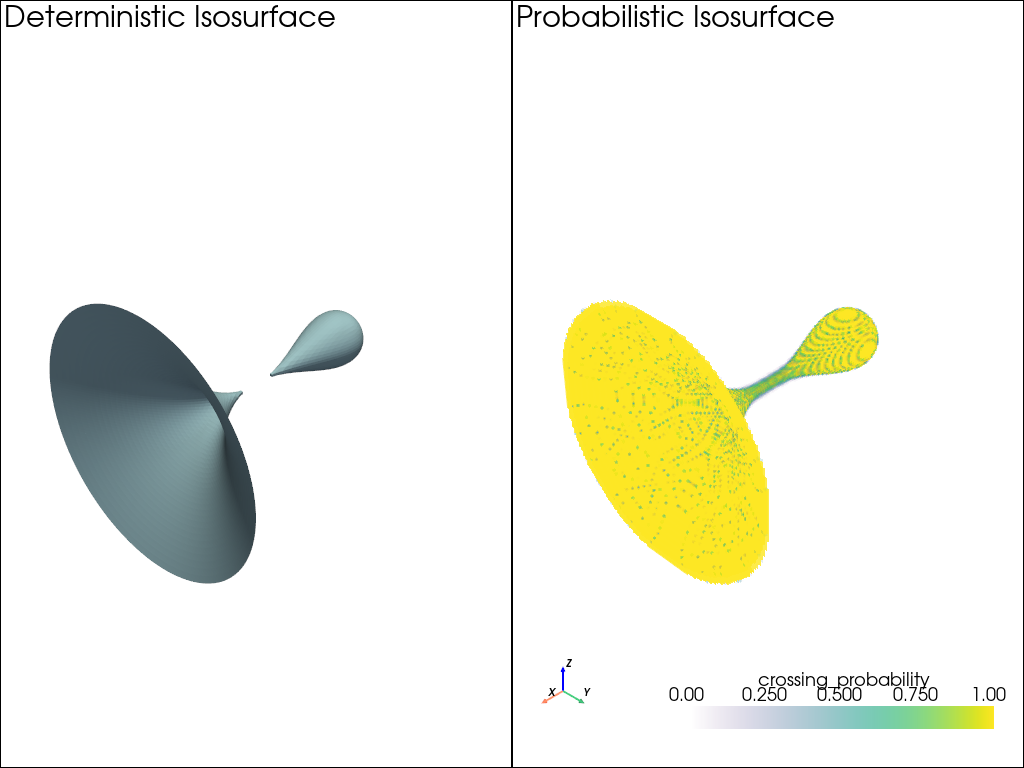

pyvista_ndarray([[[  0,   0,   0],
                  [  0,   0,   0],
                  [  0,   0,   0],
                  ...,
                  [  0,   0,   0],
                  [  0,   0,   0],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 ...,

                 [[  0,   0,   0],
                  [255, 255, 255],
                  [255, 255, 255],
                  ...,
                  [255, 255, 255],
                  [255, 255, 255],
                  [  0,   0,   0]],

                 [[  0,   0,   0],
  

In [ ]:
# Import necessary libraries
import numpy as np
import pyvista as pv
from uvisbox.Modules.ProbabilisticMarchingCubes import probabilistic_marching_cubes


# tear drop function
def tear_drop(noise_less=0.001, n_x=32, n_y=32, n_z=32, n_ens=30):
    # return 0.5*x**5 + 0.5*x**4 - y**2 - z**2

    # Generate synthetic 4D data (n_z, n_y, n_x, n_ens)
    x = np.linspace(-1, 1, n_x)
    y = np.linspace(-1, 1, n_y)
    z = np.linspace(-1, 1, n_z)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
    noise_less_F = 0.5*X**5 + 0.5*X**4 - Y**2 - Z**2

    # generate ensemble data with noise
    F = np.zeros((n_z, n_y, n_x, n_ens))
    for e in range(n_ens):
        noise = np.random.normal(0, noise_less, (n_z, n_y, n_x))
        F[:, :, :, e] = noise_less_F +  noise

    return noise_less_F, F

def spaghetti_plot(noise_less_F, isovalue=0, plotter=None):
    
    origin = (0, 0, 0)
    spacing = (1, 1, 1)
    n_z, n_y, n_x= noise_less_F.shape
    grid_dimensions = (n_z, n_y, n_x)
    grid = pv.ImageData(dimensions=grid_dimensions, origin=origin, spacing=spacing)
    # Add some data to the cell data (e.g., a 4D NumPy array)
    grid.point_data["values"] = noise_less_F.flatten(order='F')

    # Set isovalue and compute deterministic isosurface
    isovalue = 0
    iso_surface = grid.contour([isovalue], scalars="values")
    # Set up the plotter with two subplots
    plotter = pv.Plotter(shape=(1, 2))
    # Plot deterministic isosurface
    plotter.subplot(0, 0)
    plotter.add_text("Deterministic Isosurface", font_size=16)
    plotter.add_mesh(iso_surface, color='lightblue', opacity=1)

    return plotter

# Create an ensemble of scalar fields with some noise
noise_less_F, F = tear_drop(noise_less=0.001, n_x=100, n_y=100, n_z=100, n_ens=30)


isovalue = 0
plotter = pv.Plotter(shape=(1, 2))
# Create spaghetti plot for deterministic isosurface
plotter = spaghetti_plot(noise_less_F, isovalue=isovalue, plotter=plotter)

# Compute probabilistic marching cubes
plotter.subplot(0, 1)
plotter = probabilistic_marching_cubes(F, isovalue, plotter=plotter)
plotter.add_text("Probabilistic Isosurface", font_size=16)

# Link the views so camera movements are synchronized
plotter.link_views()
plotter.show()
# plotter.screenshot("probabilistic_marching_cubes_example.png")
